# 1. Import needed libraries


In [1]:
import os
import json
import warnings
from io import BytesIO
from pathlib import Path

from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings("ignore")

tf.random.set_seed(42)
np.random.seed(42)


In [2]:
pip install kaggle

# 2. Data preparation


## 2.1 Load data


In [3]:
def train_df(tr_path):
    tr_path = Path(tr_path)
    records = []

    for class_dir in sorted([p for p in tr_path.iterdir() if p.is_dir()]):
        for image_path in sorted(class_dir.iterdir()):
            if image_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}:
                records.append({'Class Path': str(image_path), 'Class': class_dir.name})

    if not records:
        raise ValueError(f'No images found under: {tr_path}')

    return pd.DataFrame(records)


In [4]:
def test_df(ts_path):
    ts_path = Path(ts_path)
    records = []

    for class_dir in sorted([p for p in ts_path.iterdir() if p.is_dir()]):
        for image_path in sorted(class_dir.iterdir()):
            if image_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}:
                records.append({'Class Path': str(image_path), 'Class': class_dir.name})

    if not records:
        raise ValueError(f'No images found under: {ts_path}')

    return pd.DataFrame(records)


In [5]:
import os
import kagglehub

# Download dataset
path = kagglehub.dataset_download("vanshvats3020/braintumormri-dataset")

# Point to Training folder
train_path = os.path.join(path, "Training")

tr_df = train_df(train_path)

100%|██████████| 157M/157M [00:09<00:00, 16.7MB/s]

Extracting files...


In [6]:
tr_df

,Class Path,Class
0,/root/.cache/kagglehub/datasets/vanshvats3020/...,glioma
1,/root/.cache/kagglehub/datasets/vanshvats3020/...,glioma
2,/root/.cache/kagglehub/datasets/vanshvats3020/...,glioma
3,/root/.cache/kagglehub/datasets/vanshvats3020/...,glioma
4,/root/.cache/kagglehub/datasets/vanshvats3020/...,glioma
...,...,...
5595,/root/.cache/kagglehub/datasets/vanshvats3020/...,pituitary
5596,/root/.cache/kagglehub/datasets/vanshvats3020/...,pituitary
5597,/root/.cache/kagglehub/datasets/vanshvats3020/...,pituitary
5598,/root/.cache/kagglehub/datasets/vanshvats3020/...,pituitary


In [7]:
import os

test_path = os.path.join(path, "Testing")
ts_df = test_df(test_path)

In [8]:
ts_df

,Class Path,Class
0,/root/.cache/kagglehub/datasets/vanshvats3020/...,glioma
1,/root/.cache/kagglehub/datasets/vanshvats3020/...,glioma
2,/root/.cache/kagglehub/datasets/vanshvats3020/...,glioma
3,/root/.cache/kagglehub/datasets/vanshvats3020/...,glioma
4,/root/.cache/kagglehub/datasets/vanshvats3020/...,glioma
...,...,...
1595,/root/.cache/kagglehub/datasets/vanshvats3020/...,pituitary
1596,/root/.cache/kagglehub/datasets/vanshvats3020/...,pituitary
1597,/root/.cache/kagglehub/datasets/vanshvats3020/...,pituitary
1598,/root/.cache/kagglehub/datasets/vanshvats3020/...,pituitary


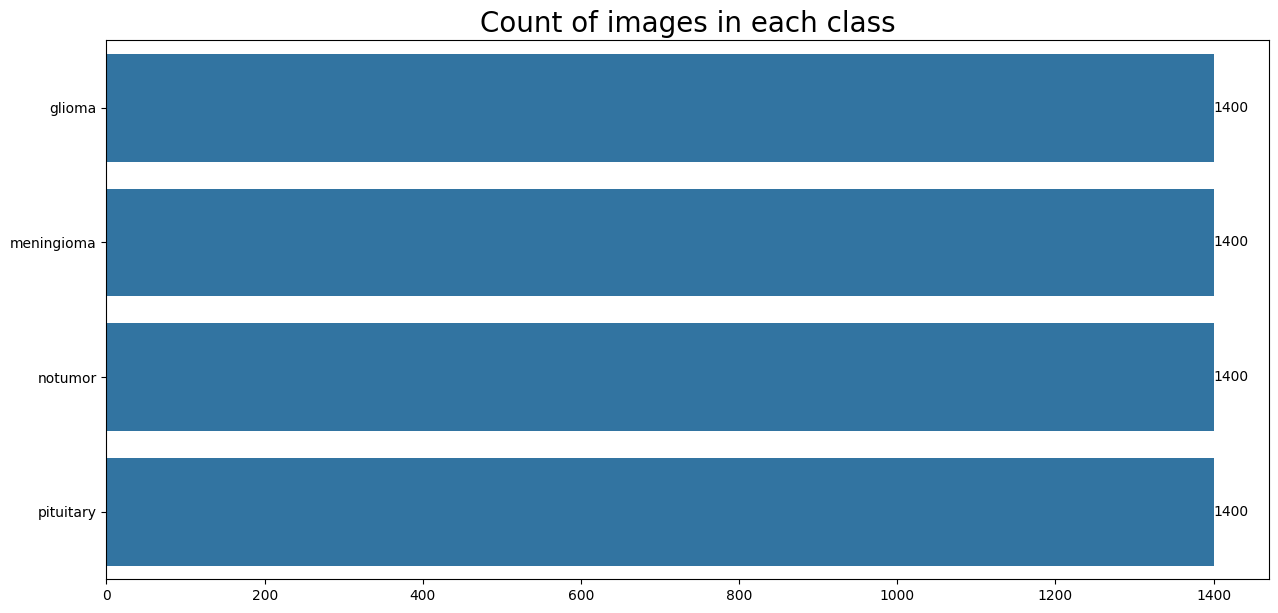

In [9]:
plt.figure(figsize=(15, 7))
ax = sns.countplot(data=tr_df, y='Class')
plt.xlabel('')
plt.ylabel('')
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
plt.show()


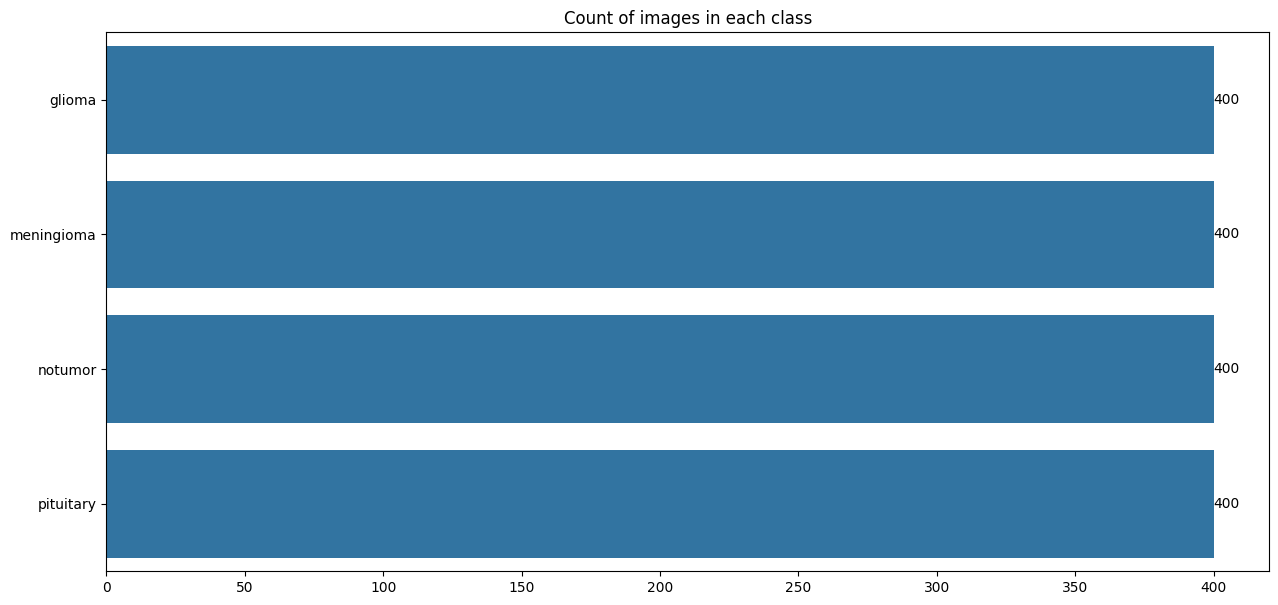

In [10]:
plt.figure(figsize=(15, 7))
ax = sns.countplot(data=ts_df, y='Class')
ax.set(xlabel='', ylabel='', title='Count of images in each class')
ax.bar_label(ax.containers[0])
plt.show()


## 2.2 Split data into train, test, valid


In [11]:
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])


In [12]:
valid_df

,Class Path,Class
1398,/root/.cache/kagglehub/datasets/vanshvats3020/...,pituitary
457,/root/.cache/kagglehub/datasets/vanshvats3020/...,meningioma
698,/root/.cache/kagglehub/datasets/vanshvats3020/...,meningioma
719,/root/.cache/kagglehub/datasets/vanshvats3020/...,meningioma
908,/root/.cache/kagglehub/datasets/vanshvats3020/...,notumor
...,...,...
81,/root/.cache/kagglehub/datasets/vanshvats3020/...,glioma
1372,/root/.cache/kagglehub/datasets/vanshvats3020/...,pituitary
1192,/root/.cache/kagglehub/datasets/vanshvats3020/...,notumor
533,/root/.cache/kagglehub/datasets/vanshvats3020/...,meningioma


## 2.3 Image preprocessing and generators


In [13]:
batch_size = 32
img_size = (299, 299)

train_gen = ImageDataGenerator(
    rescale=1/255,
    brightness_range=(0.8, 1.2),
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1/255)

tr_gen = train_gen.flow_from_dataframe(
    tr_df,
    x_col='Class Path',
    y_col='Class',
    batch_size=batch_size,
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    seed=42
)

valid_gen = train_gen.flow_from_dataframe(
    valid_df,
    x_col='Class Path',
    y_col='Class',
    batch_size=batch_size,
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

ts_gen = test_gen.flow_from_dataframe(
    ts_df,
    x_col='Class Path',
    y_col='Class',
    batch_size=16,
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)


Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


## 2.4 Getting samples from data


Found 800 validated image filenames belonging to 4 classes.


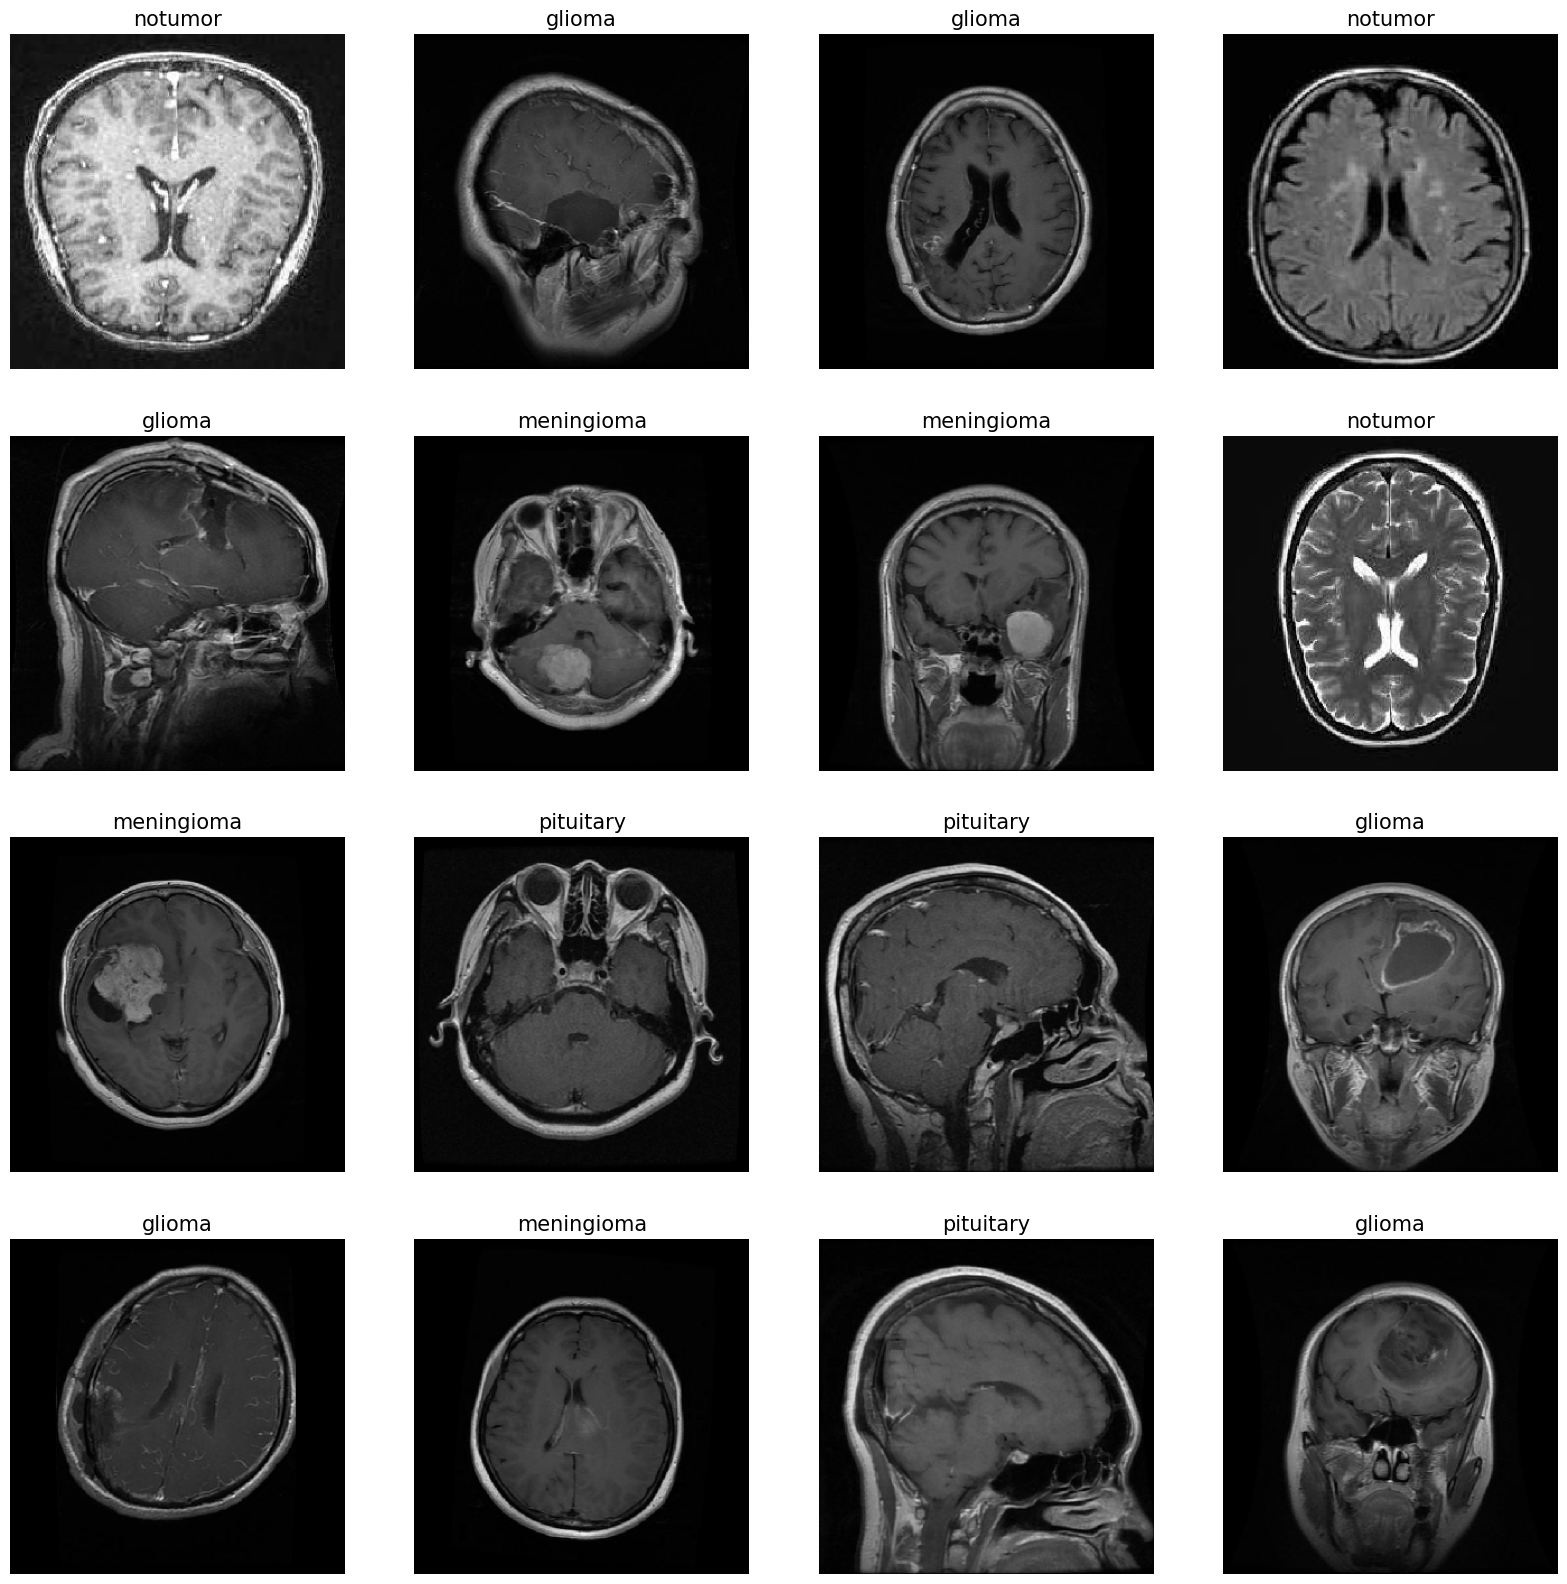

In [14]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())

preview_gen = test_gen.flow_from_dataframe(
    ts_df,
    x_col='Class Path',
    y_col='Class',
    batch_size=16,
    target_size=img_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

images, labels = next(preview_gen)

plt.figure(figsize=(20, 20))
for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4, 4, i + 1)
    plt.imshow(image)
    class_name = classes[np.argmax(label)]
    plt.title(class_name, color='k', fontsize=15)
    plt.axis('off')

plt.show()


# 3. Building Deep Learning Model


In [15]:
img_shape = (299, 299, 3)
base_model = tf.keras.applications.Xception(
    include_top=False,
    weights='imagenet',
    input_shape=img_shape,
    pooling='max'
)

base_model.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dropout(rate=0.3),
    Dense(128, activation='relu'),
    Dropout(rate=0.25),
    Dense(4, activation='softmax')
])

model.compile(
    Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

model.summary()


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

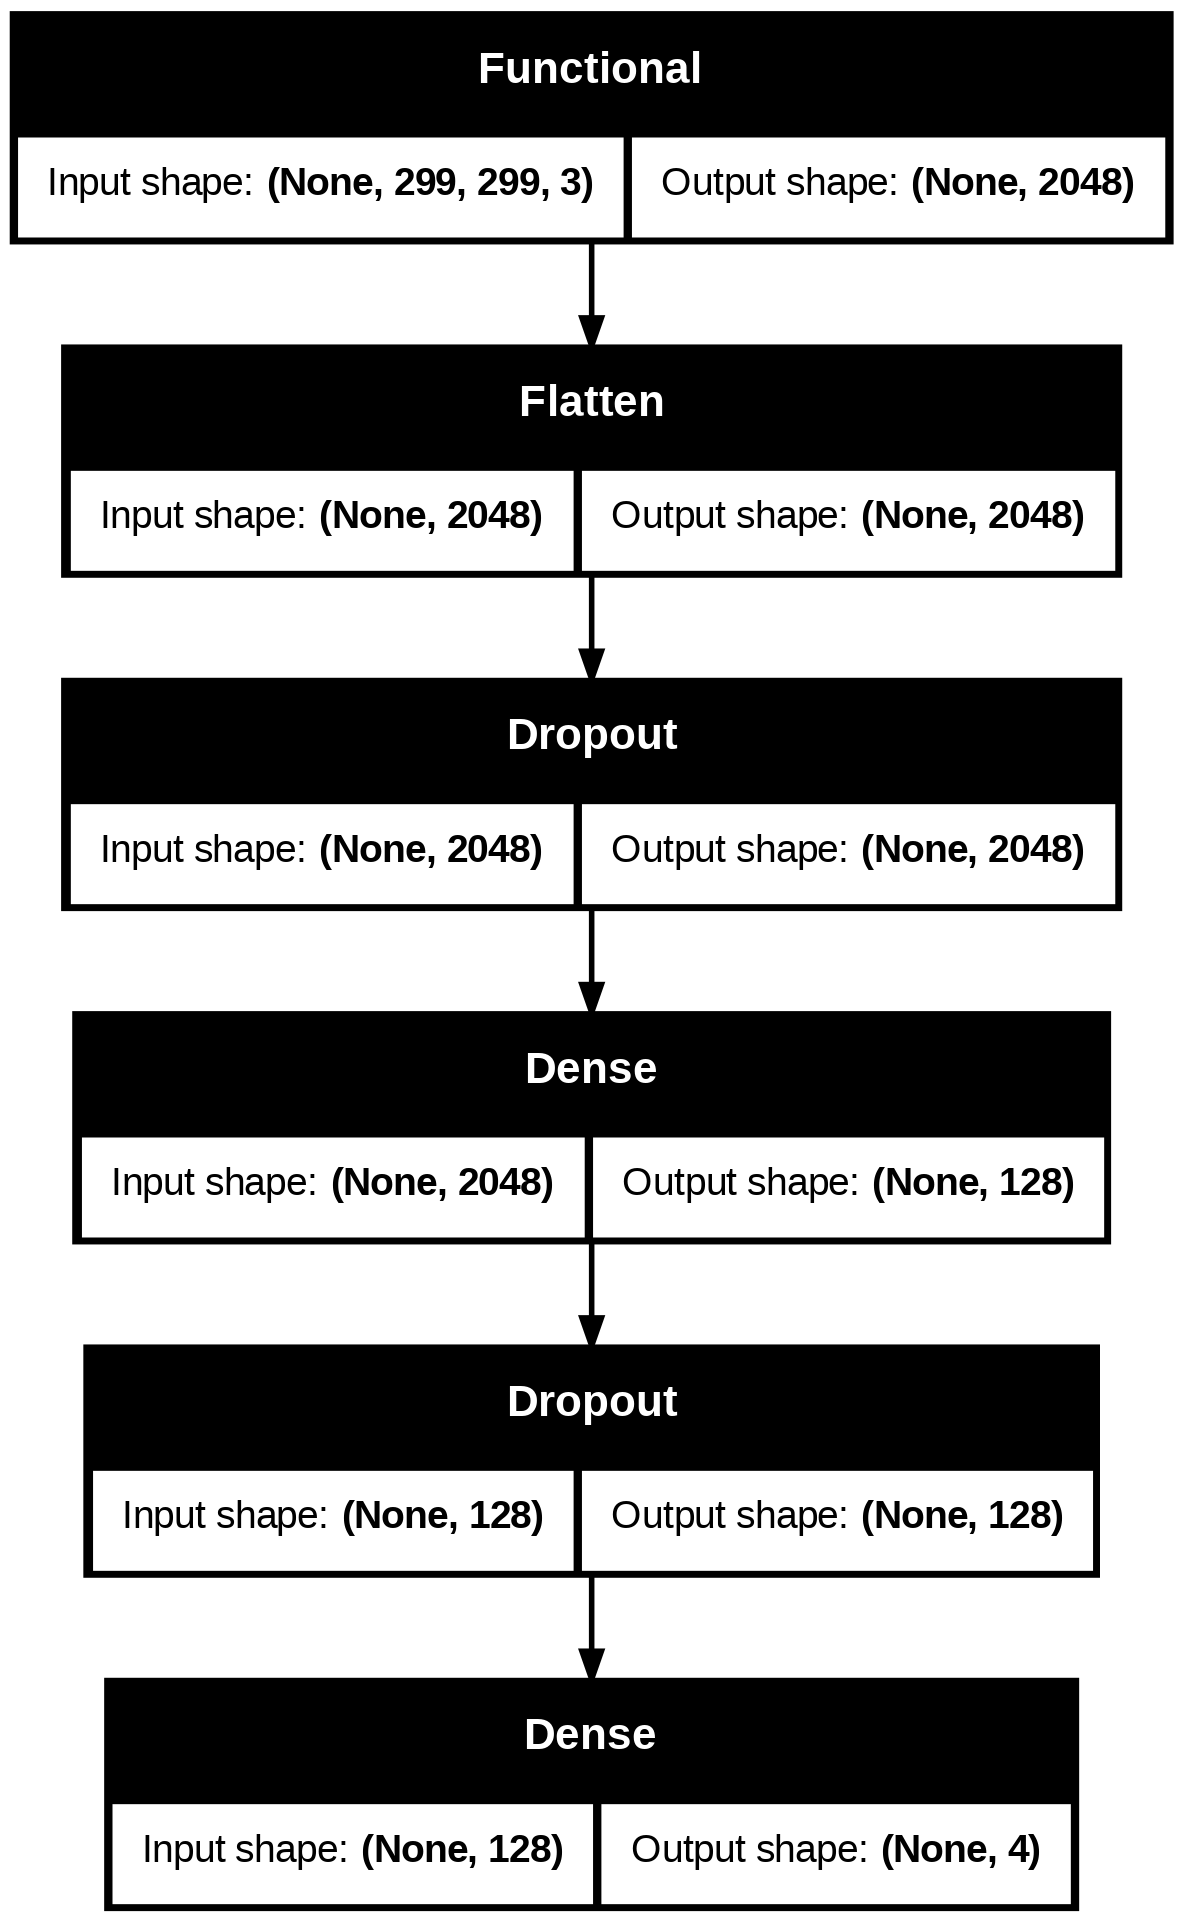

In [16]:
tf.keras.utils.plot_model(model, show_shapes=True)

# 4. Training


In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_brain_tumor_classifier.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

hist = model.fit(
    tr_gen,
    epochs=10,
    validation_data=valid_gen,
    shuffle=False,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.6388 - loss: 0.9725 - precision: 0.6734 - recall: 0.5906
Epoch 1: val_accuracy improved from None to 0.79375, saving model to best_brain_tumor_classifier.keras

Epoch 1: finished saving model to best_brain_tumor_classifier.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 131s 439ms/step - accuracy: 0.7237 - loss: 0.7179 - precision: 0.7668 - recall: 0.6757 - val_accuracy: 0.7937 - val_loss: 0.5639 - val_precision: 0.8387 - val_recall: 0.7475 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.8082 - loss: 0.5004 - precision: 0.8342 - recall: 0.7750
Epoch 2: val_accuracy improved from 0.79375 to 0.80625, saving model to best_brain_tumor_classifier.keras

Epoch 2: finished saving model to best_brain_tumor_classifier.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 64s 364ms/step - accuracy: 0.8177 - loss: 0.4768 - precision: 0.8419 - recall: 0.7871 - val_accuracy: 0.8062 - val_loss: 0.5712 - val_precision: 0.

In [18]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall', 'learning_rate'])

## 4.1 Visualize model performance


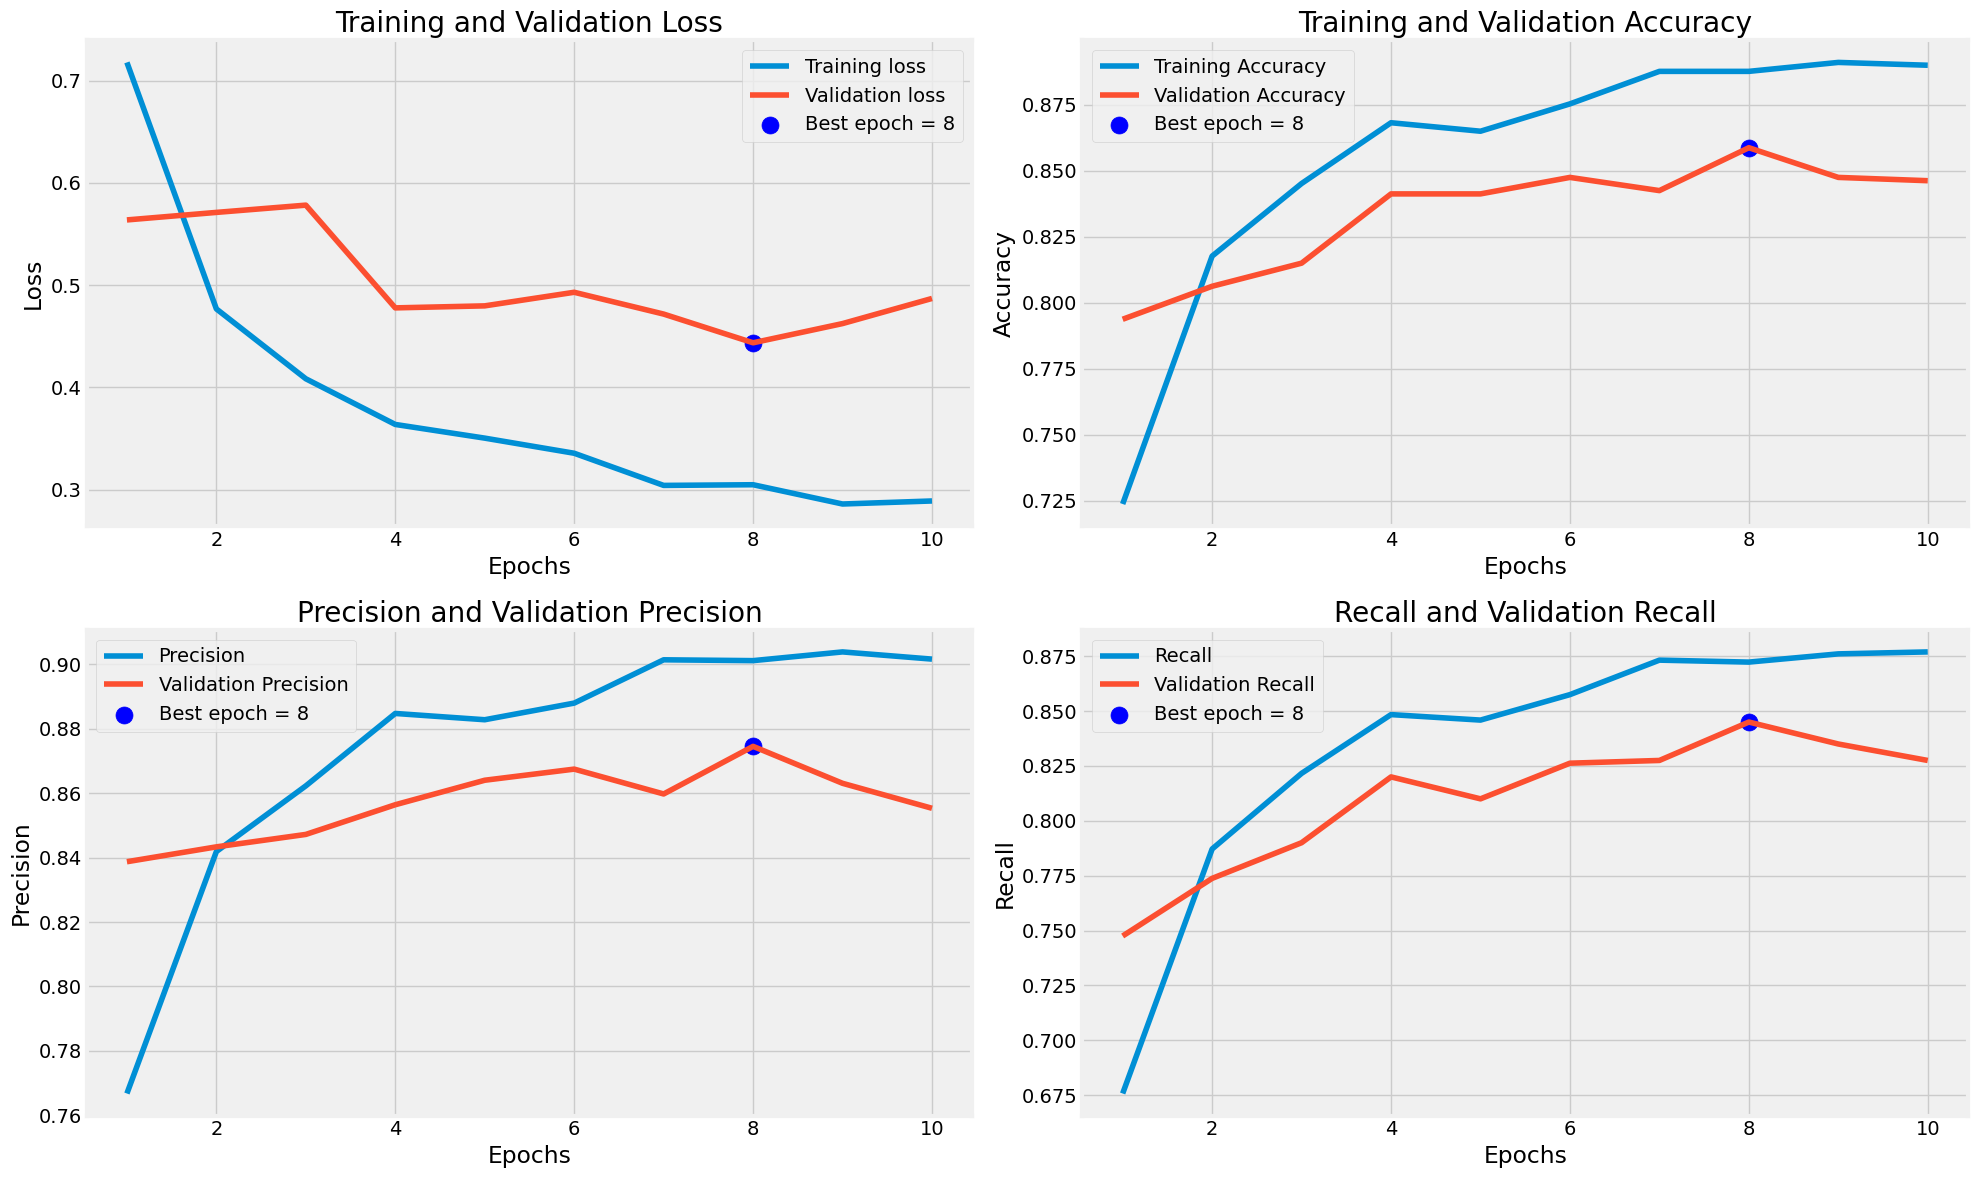

In [19]:
tr_acc = hist.history['accuracy']
tr_loss = hist.history['loss']
tr_per = hist.history['precision']
tr_recall = hist.history['recall']
val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_per = hist.history['val_precision']
val_recall = hist.history['val_recall']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'

plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')

plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, label='Training loss')
plt.plot(Epochs, val_loss, label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, label='Training Accuracy')
plt.plot(Epochs, val_acc, label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(Epochs, tr_per, label='Precision')
plt.plot(Epochs, val_per, label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Precision and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(Epochs, tr_recall, label='Recall')
plt.plot(Epochs, val_recall, label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Recall and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# 5. Testing and Evaluation


## 5.1 Evaluate


In [20]:
tr_gen.reset()
valid_gen.reset()
ts_gen.reset()

train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")


175/175 ━━━━━━━━━━━━━━━━━━━━ 54s 306ms/step - accuracy: 0.9287 - loss: 0.2099 - precision: 0.9350 - recall: 0.9216
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 333ms/step - accuracy: 0.8550 - loss: 0.4466 - precision: 0.8671 - recall: 0.8400
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 130ms/step - accuracy: 0.8637 - loss: 0.4039 - precision: 0.8776 - recall: 0.8512
Train Loss: 0.2099
Train Accuracy: 92.87%
--------------------
Validation Loss: 0.4466
Validation Accuracy: 85.50%
--------------------
Test Loss: 0.4039
Test Accuracy: 86.37%


In [21]:
ts_gen.reset()
preds = model.predict(ts_gen, verbose=0)
y_pred = np.argmax(preds, axis=1)


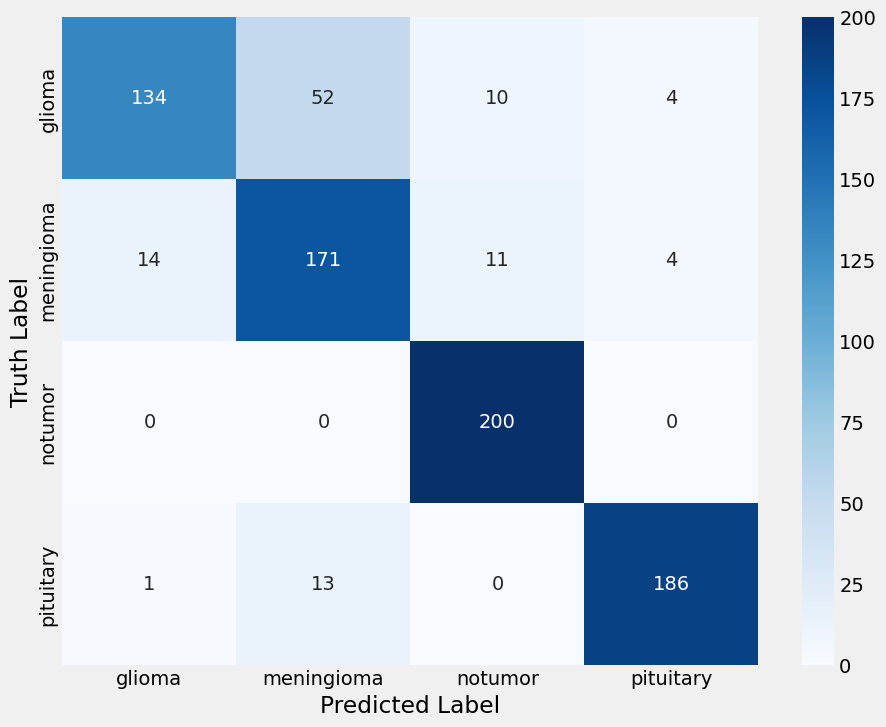

In [22]:
cm = confusion_matrix(ts_gen.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()


In [23]:
clr = classification_report(ts_gen.classes, y_pred)
print(clr)


              precision    recall  f1-score   support

           0       0.90      0.67      0.77       200
           1       0.72      0.85      0.78       200
           2       0.90      1.00      0.95       200
           3       0.96      0.93      0.94       200

    accuracy                           0.86       800
   macro avg       0.87      0.86      0.86       800
weighted avg       0.87      0.86      0.86       800



## 5.2 Single-image prediction for upload workflows


In [24]:
CLASS_NAMES = list(class_dict.keys())
FRIENDLY_LABELS = {
    'glioma': 'Glioma tumor',
    'meningioma': 'Meningioma tumor',
    'pituitary': 'Pituitary tumor',
    'notumor': 'No tumor detected'
}

def _load_image(image_input, target_size=(299, 299)):
    if isinstance(image_input, (str, os.PathLike)):
        img = Image.open(image_input)
    elif hasattr(image_input, 'read'):
        img = Image.open(image_input)
    elif isinstance(image_input, (bytes, bytearray)):
        img = Image.open(BytesIO(image_input))
    else:
        raise TypeError('image_input must be a file path, file-like object, or bytes.')

    img = img.convert('RGB')
    resized_img = img.resize(target_size)
    arr = np.asarray(resized_img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)
    return img, resized_img, arr

def predict_uploaded_image(image_input, top_k=4, show=True):
    original_img, resized_img, arr = _load_image(image_input, target_size=img_size)
    predictions = model.predict(arr, verbose=0)[0]

    order = np.argsort(predictions)[::-1]
    top_k = min(top_k, len(CLASS_NAMES))
    top_indices = order[:top_k]

    results = []
    for idx in top_indices:
        class_name = CLASS_NAMES[idx]
        results.append({
            'class_name': class_name,
            'friendly_name': FRIENDLY_LABELS.get(class_name, class_name),
            'confidence': float(predictions[idx])
        })

    best = results[0]

    if show:
        plt.figure(figsize=(12, 10))
        plt.subplot(2, 1, 1)
        plt.imshow(resized_img, cmap='gray' if np.asarray(resized_img).ndim == 2 else None)
        plt.axis('off')
        plt.title(f"Prediction: {best['friendly_name']} ({best['confidence']*100:.2f}%)")

        plt.subplot(2, 1, 2)
        bars = plt.barh([r['friendly_name'] for r in results[::-1]], [r['confidence'] for r in results[::-1]])
        plt.xlabel('Probability')
        plt.xlim(0, 1)
        ax = plt.gca()
        ax.bar_label(bars, fmt='%.2f')
        plt.tight_layout()
        plt.show()

    return {
        'predicted_class': best['class_name'],
        'predicted_label': best['friendly_name'],
        'confidence': best['confidence'],
        'top_k': results
    }


FileUpload(value={}, accept='image/*', description='Upload')

Image uploaded! Running prediction...



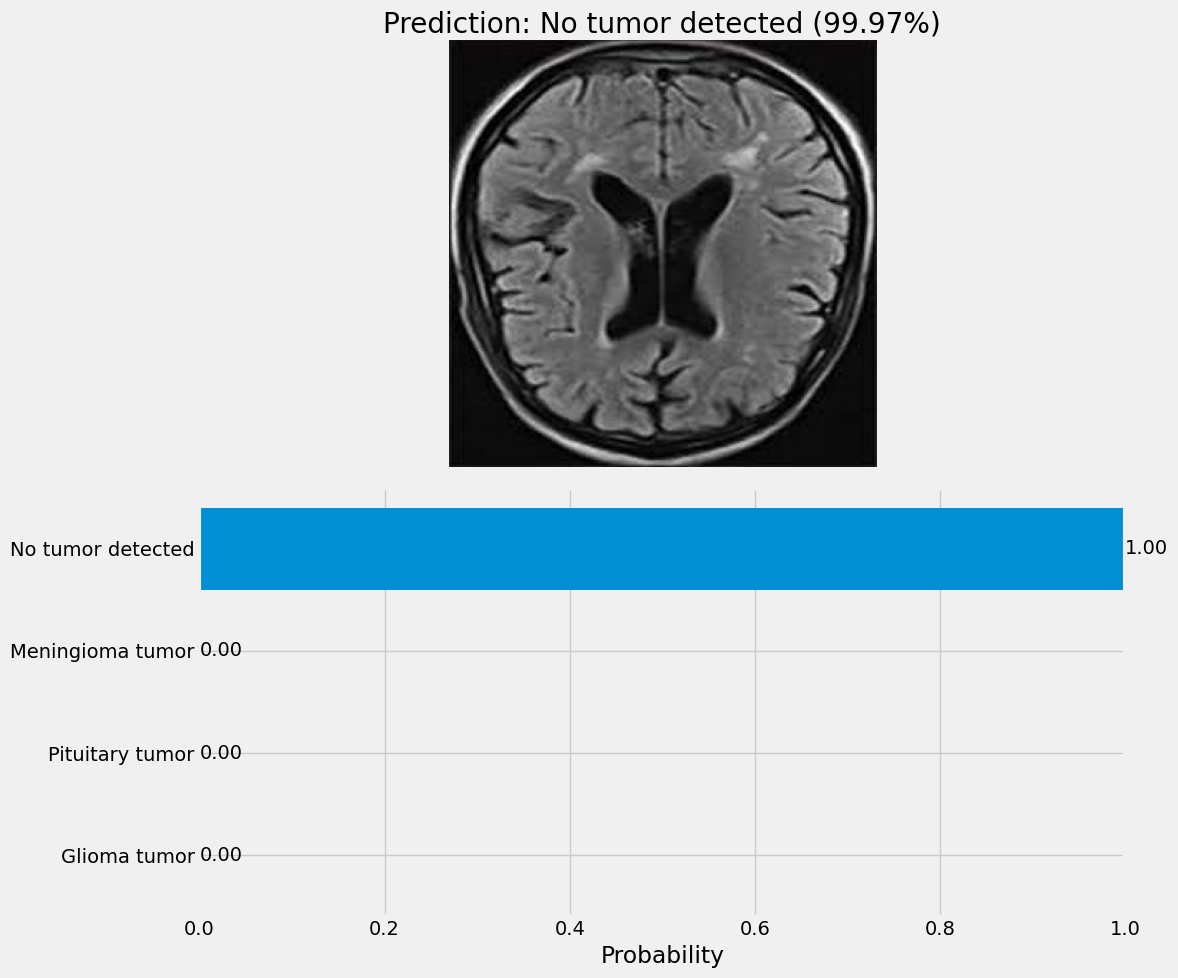


Final Result:
Prediction: No tumor detected
Confidence: 99.97%


In [29]:
from IPython.display import display
import ipywidgets as widgets

# Create upload widget
upload_widget = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

display(upload_widget)

# Function to handle upload
def on_upload_change(change):
    if upload_widget.value:
        file_info = list(upload_widget.value.values())[0]
        image_bytes = file_info['content']

        print("Image uploaded! Running prediction...\n")

        result = predict_uploaded_image(image_bytes)

        print("\nFinal Result:")
        print("Prediction:", result['predicted_label'])
        print("Confidence:", f"{result['confidence']*100:.2f}%")

upload_widget.observe(on_upload_change, names='value')

FileUpload(value={}, accept='image/*', description='Upload')

Image uploaded! Running prediction...



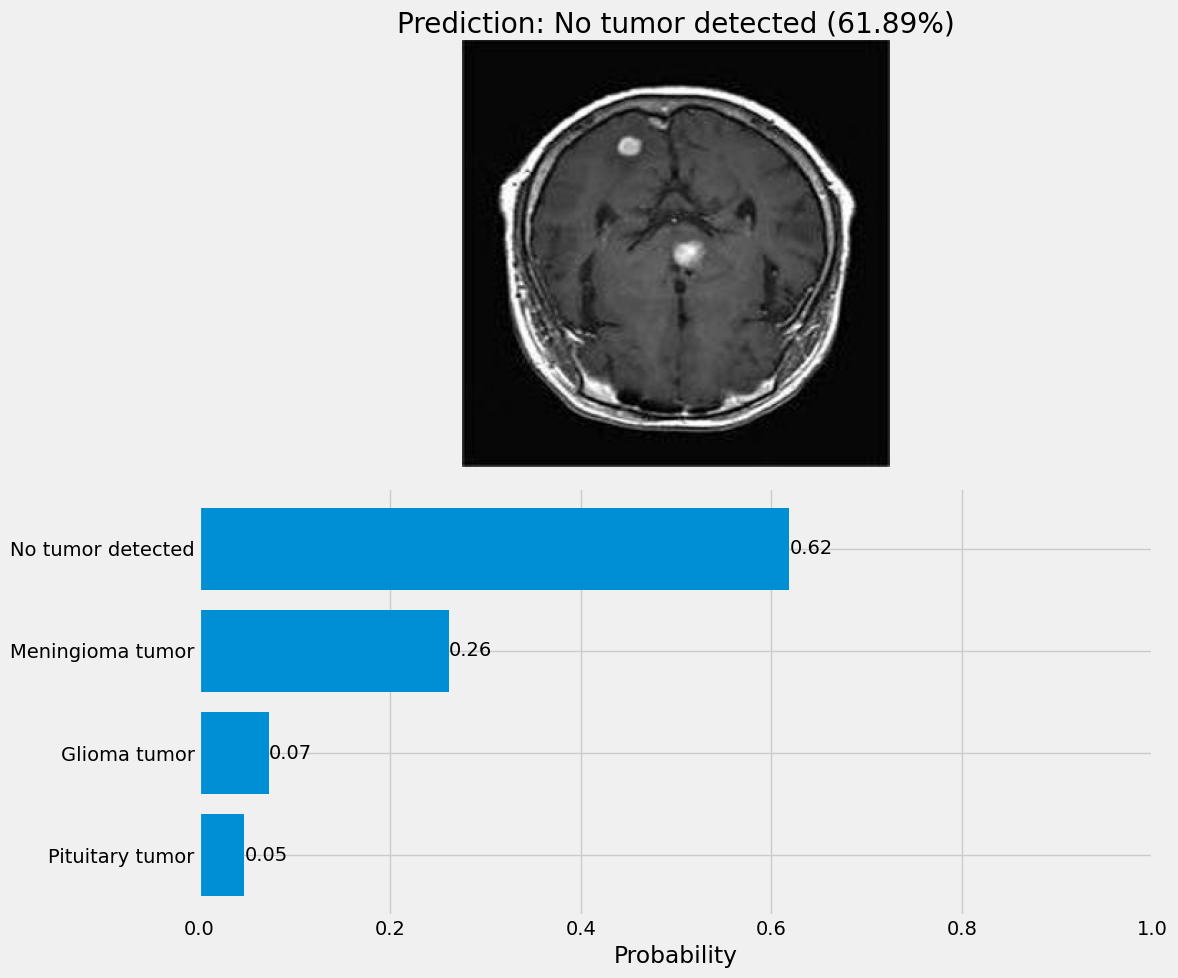


Final Result:
Prediction: No tumor detected
Confidence: 61.89%


In [30]:
from IPython.display import display
import ipywidgets as widgets

# Create upload widget
upload_widget = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

display(upload_widget)

# Function to handle upload
def on_upload_change(change):
    if upload_widget.value:
        file_info = list(upload_widget.value.values())[0]
        image_bytes = file_info['content']

        print("Image uploaded! Running prediction...\n")

        result = predict_uploaded_image(image_bytes)

        print("\nFinal Result:")
        print("Prediction:", result['predicted_label'])
        print("Confidence:", f"{result['confidence']*100:.2f}%")

upload_widget.observe(on_upload_change, names='value')

FileUpload(value={}, accept='image/*', description='Upload')

Image uploaded! Running prediction...



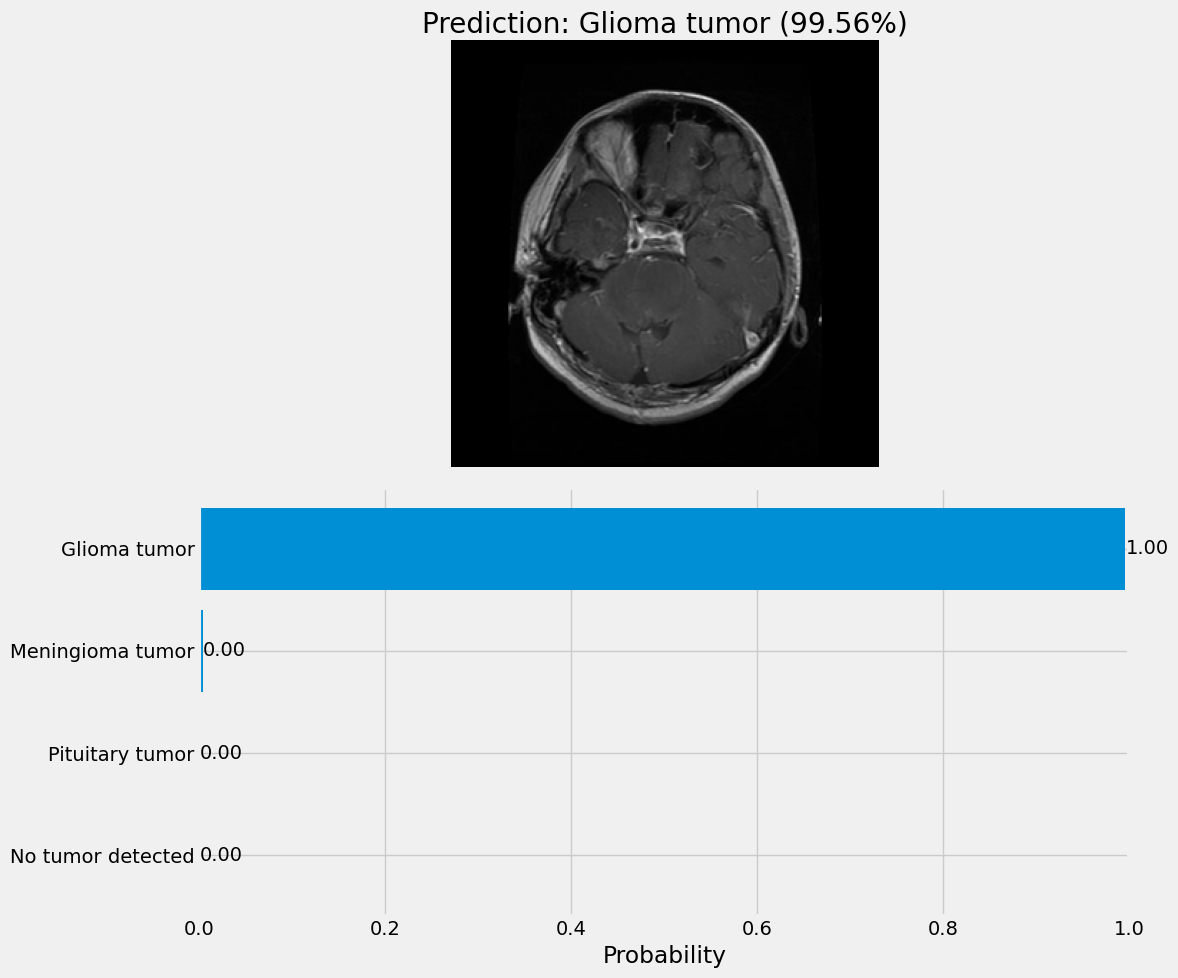


Final Result:
Prediction: Glioma tumor
Confidence: 99.56%


In [31]:
from IPython.display import display
import ipywidgets as widgets

# Create upload widget
upload_widget = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

display(upload_widget)

# Function to handle upload
def on_upload_change(change):
    if upload_widget.value:
        file_info = list(upload_widget.value.values())[0]
        image_bytes = file_info['content']

        print("Image uploaded! Running prediction...\n")

        result = predict_uploaded_image(image_bytes)

        print("\nFinal Result:")
        print("Prediction:", result['predicted_label'])
        print("Confidence:", f"{result['confidence']*100:.2f}%")

upload_widget.observe(on_upload_change, names='value')

FileUpload(value={}, accept='image/*', description='Upload')

Image uploaded! Running prediction...



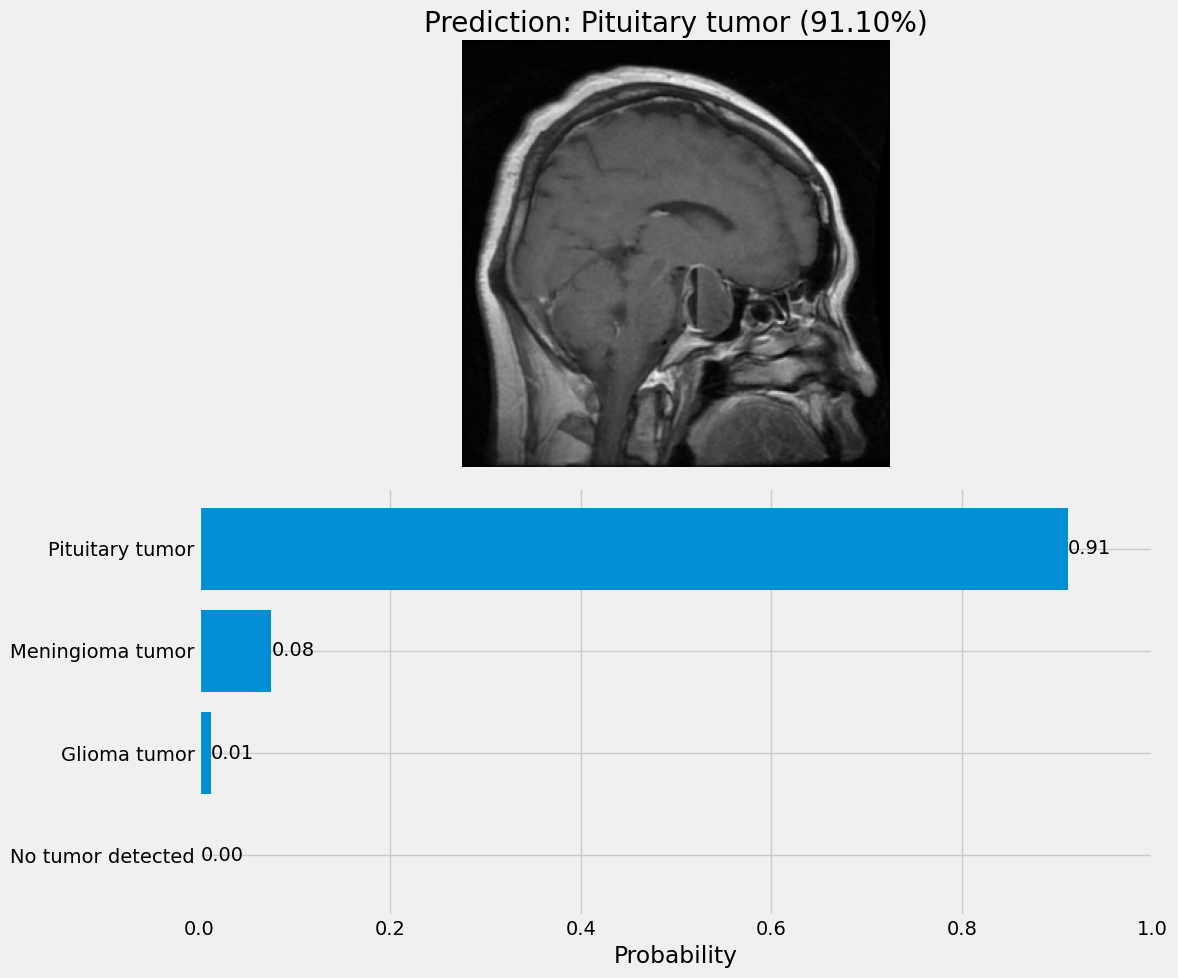


Final Result:
Prediction: Pituitary tumor
Confidence: 91.10%


In [32]:
from IPython.display import display
import ipywidgets as widgets

# Create upload widget
upload_widget = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

display(upload_widget)

# Function to handle upload
def on_upload_change(change):
    if upload_widget.value:
        file_info = list(upload_widget.value.values())[0]
        image_bytes = file_info['content']

        print("Image uploaded! Running prediction...\n")

        result = predict_uploaded_image(image_bytes)

        print("\nFinal Result:")
        print("Prediction:", result['predicted_label'])
        print("Confidence:", f"{result['confidence']*100:.2f}%")

upload_widget.observe(on_upload_change, names='value')

FileUpload(value={}, accept='image/*', description='Upload')

Image uploaded! Running prediction...



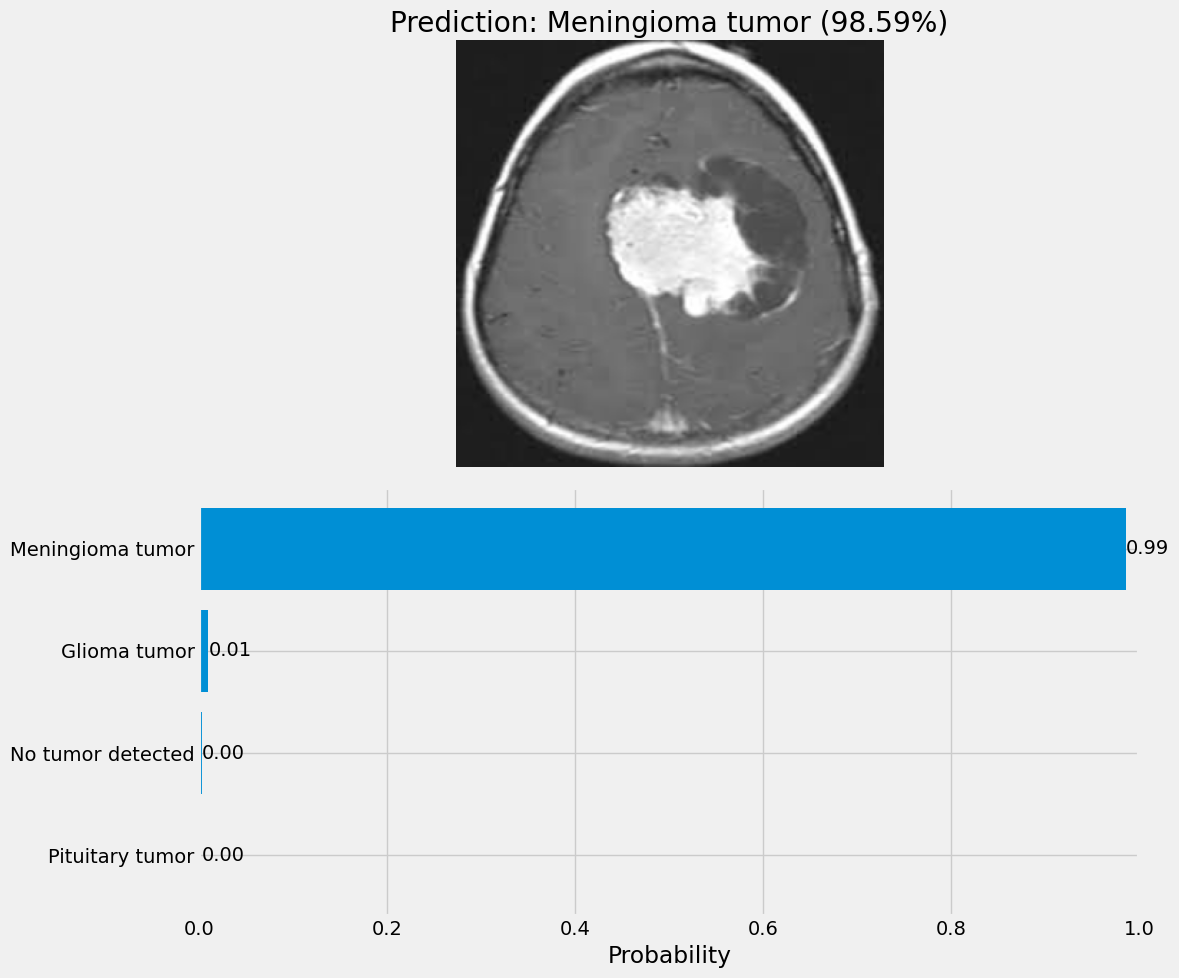


Final Result:
Prediction: Meningioma tumor
Confidence: 98.59%


In [33]:
from IPython.display import display
import ipywidgets as widgets

# Create upload widget
upload_widget = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

display(upload_widget)

# Function to handle upload
def on_upload_change(change):
    if upload_widget.value:
        file_info = list(upload_widget.value.values())[0]
        image_bytes = file_info['content']

        print("Image uploaded! Running prediction...\n")

        result = predict_uploaded_image(image_bytes)

        print("\nFinal Result:")
        print("Prediction:", result['predicted_label'])
        print("Confidence:", f"{result['confidence']*100:.2f}%")

upload_widget.observe(on_upload_change, names='value')